In [1]:
import os
import time
import json
import copy
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings('ignore')

In [2]:
PROCESSED_DIR = '/kaggle/input/datasets/maryama23/osr-processed-data/processed'   
EXPORT_PATH   = 'ocr_model.pth'
NUM_CLASSES   = 26
SEED          = 42
ALPHABET      = list('ABCDEFGHIJKLMNOPQRSTUVWXYZ')

torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: Tesla T4
Memory: 15.6 GB


In [ ]:
# CNN: 28×28 grayscale
cnn_train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1), # one RGB channel
    transforms.RandomRotation(15), # to be able avoid change in rotation ---> data augmentation
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), shear=5), # no-rotation , up-right 10% , so the model don't depend on position of object , shear --> slope 
    transforms.ToTensor(), # ---> to pytorch tensor , from [0 , 255] -> [ 0.0 , 1.0]
    transforms.Normalize((0.1307,), (0.3081,)), # normalization : Mean -> 0.1307 , std : 0.3081
])


cnn_eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])


# MobileNetV2: upscale to 224×224, convert grayscale → 3-channel
mobilenet_train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((224, 224)), # لأن MobileNetV2 مدرب أساسًا على ImageNet.
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), shear=5),
    transforms.Grayscale(num_output_channels=3),  # repeat channel
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),  # ImageNet stats
])

mobilenet_eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])


BATCH_SIZE = 256 # how much photo each iteration .


def make_loaders(train_tf, eval_tf, batch_size=BATCH_SIZE):
    train_ds = datasets.ImageFolder(os.path.join(PROCESSED_DIR, 'train'), transform=train_tf)
    val_ds   = datasets.ImageFolder(os.path.join(PROCESSED_DIR, 'val'),   transform=eval_tf)
    test_ds  = datasets.ImageFolder(os.path.join(PROCESSED_DIR, 'test'),  transform=eval_tf)

    import platform
    # عدد الـ processes المستخدمة لتحميل البيانات
    nw = 0 if platform.system() == 'Windows' else 2 # 0 -> no parallel processing / multiple processing , may windows crash of it
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=nw, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=nw, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=nw, pin_memory=True)

    return train_loader, val_loader, test_loader

cnn_train_loader, cnn_val_loader, cnn_test_loader = make_loaders(cnn_train_transform, cnn_eval_transform)
mob_train_loader, mob_val_loader, mob_test_loader = make_loaders(mobilenet_train_transform, mobilenet_eval_transform, batch_size=64)

print(f"CNN  — Train: {len(cnn_train_loader.dataset):,}  Val: {len(cnn_val_loader.dataset):,}  Test: {len(cnn_test_loader.dataset):,}")
print(f"MNet — Train: {len(mob_train_loader.dataset):,}  Val: {len(mob_val_loader.dataset):,}  Test: {len(mob_test_loader.dataset):,}")

CNN  — Train: 260,714  Val: 55,868  Test: 55,868
MNet — Train: 260,714  Val: 55,868  Test: 55,868


In [ ]:
class OCR_CNN(nn.Module):
    """
    Custom CNN for 28×28 grayscale handwritten letter recognition.
    Architecture:
        Block 1: Conv(1→32, 3×3) → BN → ReLU → Conv(32→32) → BN → ReLU → MaxPool → Dropout(0.25)
        Block 2: Conv(32→64, 3×3) → BN → ReLU → Conv(64→64) → BN → ReLU → MaxPool → Dropout(0.25)
        Block 3: Conv(64→128, 3×3) → BN → ReLU → AdaptiveAvgPool
        Head   : FC(128→256) → ReLU → Dropout(0.5) → FC(256→26)
    """
    def __init__(self, num_classes=26):
        super().__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True), # convolution : feature maps with filters, 1-> input channel : gray , 32-> filters number , 3-> kernal size , padding=1 to save the same size 
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.25),
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.25),
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 256), nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )


    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        return self.head(x)


# Quick architecture check
model_cnn = OCR_CNN(NUM_CLASSES).to(DEVICE)
dummy = torch.zeros(2, 1, 28, 28).to(DEVICE)
out = model_cnn(dummy)
print(f"CNN output shape: {out.shape}")

total_params = sum(p.numel() for p in model_cnn.parameters())
trainable_params = sum(p.numel() for p in model_cnn.parameters() if p.requires_grad)
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")

CNN output shape: torch.Size([2, 26])
Total parameters     : 179,194
Trainable parameters : 179,194


In [5]:
def build_mobilenetv2(num_classes=26, freeze_backbone=True):
    """
    MobileNetV2 with modified classifier head for 26-class OCR.
    Strategy:
      Phase 1 (epochs 1-5)  : Freeze backbone, train head only   → fast convergence
      Phase 2 (epochs 6-20) : Unfreeze all layers, fine-tune     → best accuracy
    """
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

    if freeze_backbone:
        for param in model.features.parameters():
            param.requires_grad = False

    # Replace classifier head
    in_features = model.classifier[1].in_features  # 1280
    model.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, 512),
        nn.ReLU(inplace=True),
        nn.Dropout(0.3),
        nn.Linear(512, num_classes),
    )
    return model

model_mobilenet = build_mobilenetv2(NUM_CLASSES, freeze_backbone=True).to(DEVICE)

frozen = sum(1 for p in model_mobilenet.features.parameters() if not p.requires_grad)
trainable = sum(p.numel() for p in model_mobilenet.parameters() if p.requires_grad)
print(f"MobileNetV2 — Trainable parameters (phase 1): {trainable:,}")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 124MB/s]

MobileNetV2 — Trainable parameters (phase 1): 669,210


In [6]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += images.size(0)
    return total_loss / total, 100.0 * correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += images.size(0)
    return total_loss / total, 100.0 * correct / total


def train_model(model, train_loader, val_loader, num_epochs,
                lr=1e-3, weight_decay=1e-4, patience=7,
                scheduler_type='cosine', model_name='model'):
    """
    Full training loop with:
    - CrossEntropyLoss
    - AdamW optimizer
    - Cosine or StepLR scheduler
    - Early stopping (patience=7)
    - Best model checkpointing
    Returns: history dict, best model state dict
    """
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                            lr=lr, weight_decay=weight_decay)

    if scheduler_type == 'cosine':
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)
    else:
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
    best_val_acc = 0.0
    best_state = None
    best_epoch = 0
    patience_counter = 0

    print(f"\n{'─'*60}")
    print(f"Training: {model_name} for {num_epochs} epochs")
    print(f"{'─'*60}")
    print(f"{'Ep':>4} {'Tr Loss':>9} {'Tr Acc':>8} {'Va Loss':>9} {'Va Acc':>8} {'LR':>10} {'Time':>7}")

    for epoch in range(1, num_epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
        va_loss, va_acc = evaluate(model, val_loader, criterion, DEVICE)
        scheduler.step()

        current_lr = optimizer.param_groups[0]['lr']
        elapsed = time.time() - t0

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(va_loss)
        history['val_acc'].append(va_acc)
        history['lr'].append(current_lr)

        marker = " ★" if va_acc > best_val_acc else ""
        print(f"{epoch:>4} {tr_loss:>9.4f} {tr_acc:>7.2f}% {va_loss:>9.4f} {va_acc:>7.2f}%"
              f" {current_lr:>10.2e} {elapsed:>6.1f}s{marker}")

        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\nEarly stopping at epoch {epoch}. Best val acc: {best_val_acc:.2f}% at epoch {best_epoch}.")
                break

    history['best_val_acc'] = best_val_acc
    history['best_epoch'] = best_epoch
    print(f"\nBest Val Accuracy: {best_val_acc:.2f}% at Epoch {best_epoch}")
    return history, best_state

print("Training functions defined.")

Training functions defined.


In [7]:
model_cnn = OCR_CNN(NUM_CLASSES).to(DEVICE)

cnn_history, cnn_best_state = train_model(
    model=model_cnn,
    train_loader=cnn_train_loader,
    val_loader=cnn_val_loader,
    num_epochs=30,
    lr=1e-3,
    weight_decay=1e-4,
    patience=7,
    scheduler_type='cosine',
    model_name='OCR_CNN (from scratch)'
)



────────────────────────────────────────────────────────────
Training: OCR_CNN (from scratch) for 30 epochs
────────────────────────────────────────────────────────────
  Ep   Tr Loss   Tr Acc   Va Loss   Va Acc         LR    Time
   1    1.2486   81.49%    0.7868   97.25%   9.97e-04 1282.0s ★
   2    0.8594   95.68%    0.7376   98.38%   9.89e-04  330.3s ★
   3    0.8131   96.81%    0.7254   98.68%   9.76e-04  327.5s ★
   4    0.7921   97.22%    0.7056   98.80%   9.57e-04  322.4s ★
   5    0.7780   97.52%    0.6994   98.79%   9.33e-04  320.3s
   6    0.7684   97.68%    0.6985   98.85%   9.05e-04  312.3s ★
   7    0.7611   97.82%    0.6913   98.89%   8.72e-04  307.6s ★
   8    0.7554   97.90%    0.6907   98.95%   8.35e-04  303.4s ★
   9    0.7506   97.98%    0.6884   98.97%   7.94e-04  301.7s ★
  10    0.7464   98.03%    0.6851   99.04%   7.50e-04  300.7s ★
  11    0.7430   98.10%    0.6788   99.06%   7.04e-04  303.5s ★
  12    0.7390   98.21%    0.6776   99.03%   6.55e-04  299.0s
  13

In [8]:
# ─── Phase 1: Head only ────────────────────────────────────────────────────
model_mobilenet = build_mobilenetv2(NUM_CLASSES, freeze_backbone=True).to(DEVICE)

mob_history_phase1, mob_best_p1 = train_model(
    model=model_mobilenet,
    train_loader=mob_train_loader,
    val_loader=mob_val_loader,
    num_epochs=5,
    lr=1e-3,
    weight_decay=1e-4,
    patience=10,
    scheduler_type='step',
    model_name='MobileNetV2 Phase 1 (head only)'
)

# Load best phase-1 weights
model_mobilenet.load_state_dict(mob_best_p1)


────────────────────────────────────────────────────────────
Training: MobileNetV2 Phase 1 (head only) for 5 epochs
────────────────────────────────────────────────────────────
  Ep   Tr Loss   Tr Acc   Va Loss   Va Acc         LR    Time
   1    1.3525   75.92%    1.1105   85.05%   1.00e-03  637.0s ★
   2    1.2450   80.17%    1.0686   86.50%   1.00e-03  638.1s ★
   3    1.2170   81.30%    1.0728   85.88%   1.00e-03  656.7s
   4    1.1978   82.00%    1.0722   86.17%   1.00e-03  653.3s
   5    1.1891   82.34%    1.0241   87.60%   1.00e-03  640.3s ★

Best Val Accuracy: 87.60% at Epoch 5


<All keys matched successfully>

In [9]:
# ─── Phase 2: Fine-tune all layers ─────────────────────────────────────────
for param in model_mobilenet.features.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model_mobilenet.parameters() if p.requires_grad)
print(f"MobileNetV2 Phase 2 — Trainable parameters: {trainable:,}")

mob_history_phase2, mob_best_state = train_model(
    model=model_mobilenet,
    train_loader=mob_train_loader,
    val_loader=mob_val_loader,
    num_epochs=20,
    lr=5e-5,      # Much lower LR for fine-tuning
    weight_decay=1e-4,
    patience=7,
    scheduler_type='cosine',
    model_name='MobileNetV2 Phase 2 (full fine-tune)'
)

# Merge phase histories for plotting
mob_history = {
    k: mob_history_phase1[k] + mob_history_phase2[k]
    for k in ['train_loss', 'train_acc', 'val_loss', 'val_acc', 'lr']
}
mob_history['best_val_acc'] = mob_history_phase2['best_val_acc']  # best acc from fine-tune phase
mob_history['best_epoch']   = 5 + mob_history_phase2['best_epoch']

MobileNetV2 Phase 2 — Trainable parameters: 2,893,082

────────────────────────────────────────────────────────────
Training: MobileNetV2 Phase 2 (full fine-tune) for 20 epochs
────────────────────────────────────────────────────────────
  Ep   Tr Loss   Tr Acc   Va Loss   Va Acc         LR    Time
   1    0.7981   97.08%    0.6771   98.99%   4.97e-05 1097.5s ★
   2    0.7141   98.75%    0.6609   99.13%   4.88e-05 1098.4s ★
   3    0.6924   99.03%    0.6537   99.27%   4.73e-05 1100.4s ★
   4    0.6810   99.21%    0.6527   99.27%   4.53e-05 1099.8s ★
   5    0.6738   99.30%    0.6493   99.32%   4.28e-05 1099.3s ★
   6    0.6683   99.39%    0.6478   99.35%   3.99e-05 1095.9s ★
   7    0.6645   99.46%    0.6470   99.37%   3.66e-05 1096.1s ★
   8    0.6612   99.53%    0.6449   99.46%   3.31e-05 1095.9s ★
   9    0.6587   99.58%    0.6425   99.51%   2.93e-05 1095.8s ★
  10    0.6562   99.63%    0.6423   99.53%   2.55e-05 1111.1s ★
  11    0.6539   99.68%    0.6422   99.50%   2.17e-05 1103.7

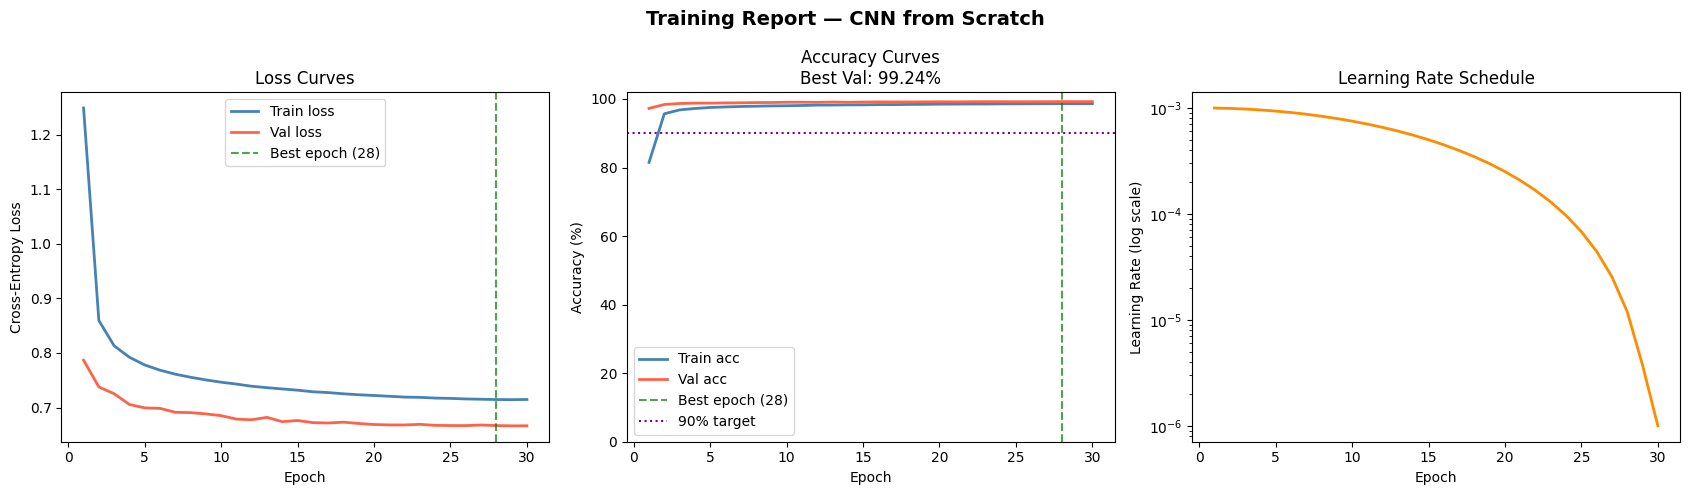

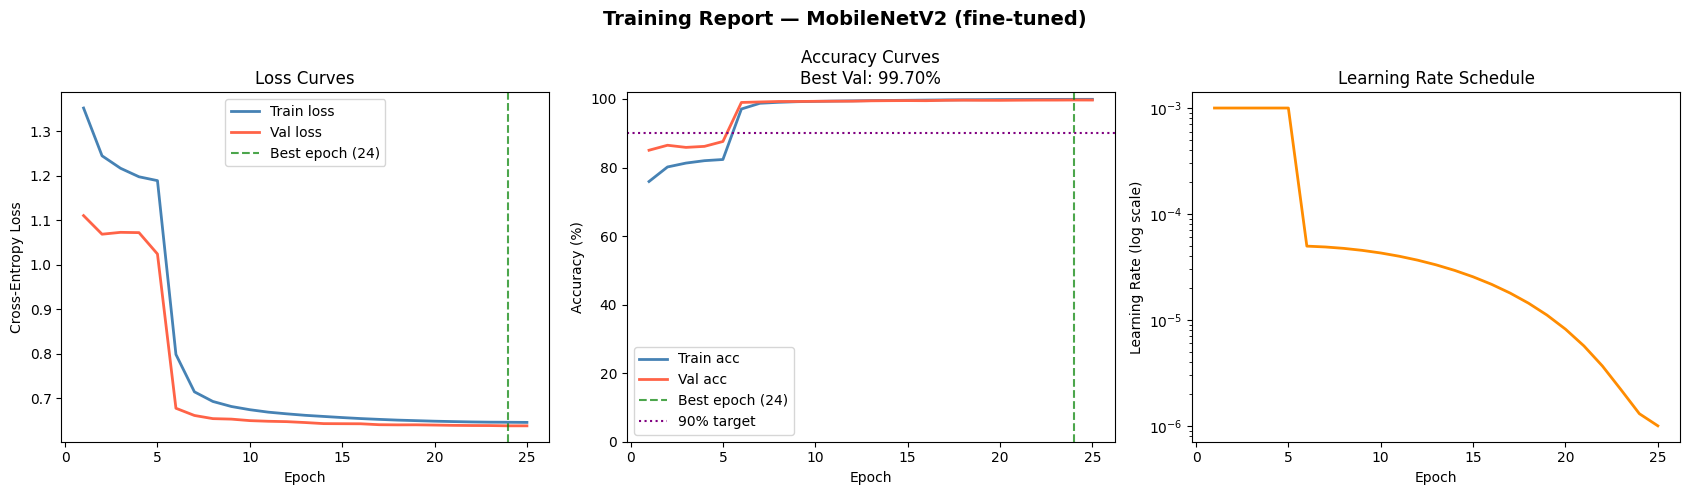

In [10]:
def plot_training_curves(history, model_name, save_path=None):
    epochs = range(1, len(history['train_loss']) + 1)
    best_ep = history.get('best_epoch', np.argmax(history['val_acc']) + 1)
    best_acc = max(history['val_acc'])

    fig, axes = plt.subplots(1, 3, figsize=(17, 5))
    fig.suptitle(f'Training Report — {model_name}', fontsize=14, fontweight='bold')

    # Loss
    axes[0].plot(epochs, history['train_loss'], label='Train loss', color='steelblue', linewidth=2)
    axes[0].plot(epochs, history['val_loss'],   label='Val loss',   color='tomato',    linewidth=2)
    axes[0].axvline(best_ep, color='green', linestyle='--', alpha=0.7, label=f'Best epoch ({best_ep})')
    axes[0].set_title('Loss Curves')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Cross-Entropy Loss')
    axes[0].legend()

    # Accuracy
    axes[1].plot(epochs, history['train_acc'], label='Train acc', color='steelblue', linewidth=2)
    axes[1].plot(epochs, history['val_acc'],   label='Val acc',   color='tomato',    linewidth=2)
    axes[1].axvline(best_ep, color='green', linestyle='--', alpha=0.7, label=f'Best epoch ({best_ep})')
    axes[1].axhline(90, color='purple', linestyle=':', linewidth=1.5, label='90% target')
    axes[1].set_title(f'Accuracy Curves\nBest Val: {best_acc:.2f}%')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].legend()
    axes[1].set_ylim(0, 102)

    # Learning rate
    axes[2].semilogy(epochs, history['lr'], color='darkorange', linewidth=2)
    axes[2].set_title('Learning Rate Schedule')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Learning Rate (log scale)')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=120)
    plt.show()


plot_training_curves(cnn_history,  'CNN from Scratch',         'report_cnn_curves.png')
plot_training_curves(mob_history,  'MobileNetV2 (fine-tuned)', 'report_mobilenet_curves.png')

In [11]:
@torch.no_grad()
def get_all_preds_labels(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    for images, labels in loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())
    return np.array(all_preds), np.array(all_labels)


# ─── CNN Evaluation ────────────────────────────────────────────────────────
model_cnn.load_state_dict(cnn_best_state)
cnn_preds, cnn_labels = get_all_preds_labels(model_cnn, cnn_test_loader, DEVICE)
cnn_test_acc = 100.0 * (cnn_preds == cnn_labels).mean()

print(f"\nCNN Test Accuracy: {cnn_test_acc:.2f}%")
print("\nClassification Report (CNN):")
print(classification_report(cnn_labels, cnn_preds, target_names=ALPHABET))

# ─── MobileNetV2 Evaluation ────────────────────────────────────────────────
model_mobilenet.load_state_dict(mob_best_state)
mob_preds, mob_labels = get_all_preds_labels(model_mobilenet, mob_test_loader, DEVICE)
mob_test_acc = 100.0 * (mob_preds == mob_labels).mean()

print(f"\nMobileNetV2 Test Accuracy: {mob_test_acc:.2f}%")
print("\nClassification Report (MobileNetV2):")
print(classification_report(mob_labels, mob_preds, target_names=ALPHABET))


CNN Test Accuracy: 99.23%

Classification Report (CNN):
              precision    recall  f1-score   support

           A       0.99      1.00      1.00      2080
           B       0.99      1.00      0.99      1300
           C       0.99      0.99      0.99      3511
           D       0.98      0.96      0.97      1520
           E       1.00      0.99      0.99      1716
           F       0.98      0.99      0.99       175
           G       1.00      0.98      0.99       864
           H       0.99      0.98      0.99      1083
           I       0.97      0.99      0.98       168
           J       0.98      0.98      0.98      1274
           K       0.99      0.98      0.98       841
           L       0.99      0.99      0.99      1738
           M       0.99      1.00      0.99      1850
           N       0.99      0.99      0.99      2852
           O       0.99      1.00      0.99      8674
           P       1.00      1.00      1.00      2901
           Q       0.99 

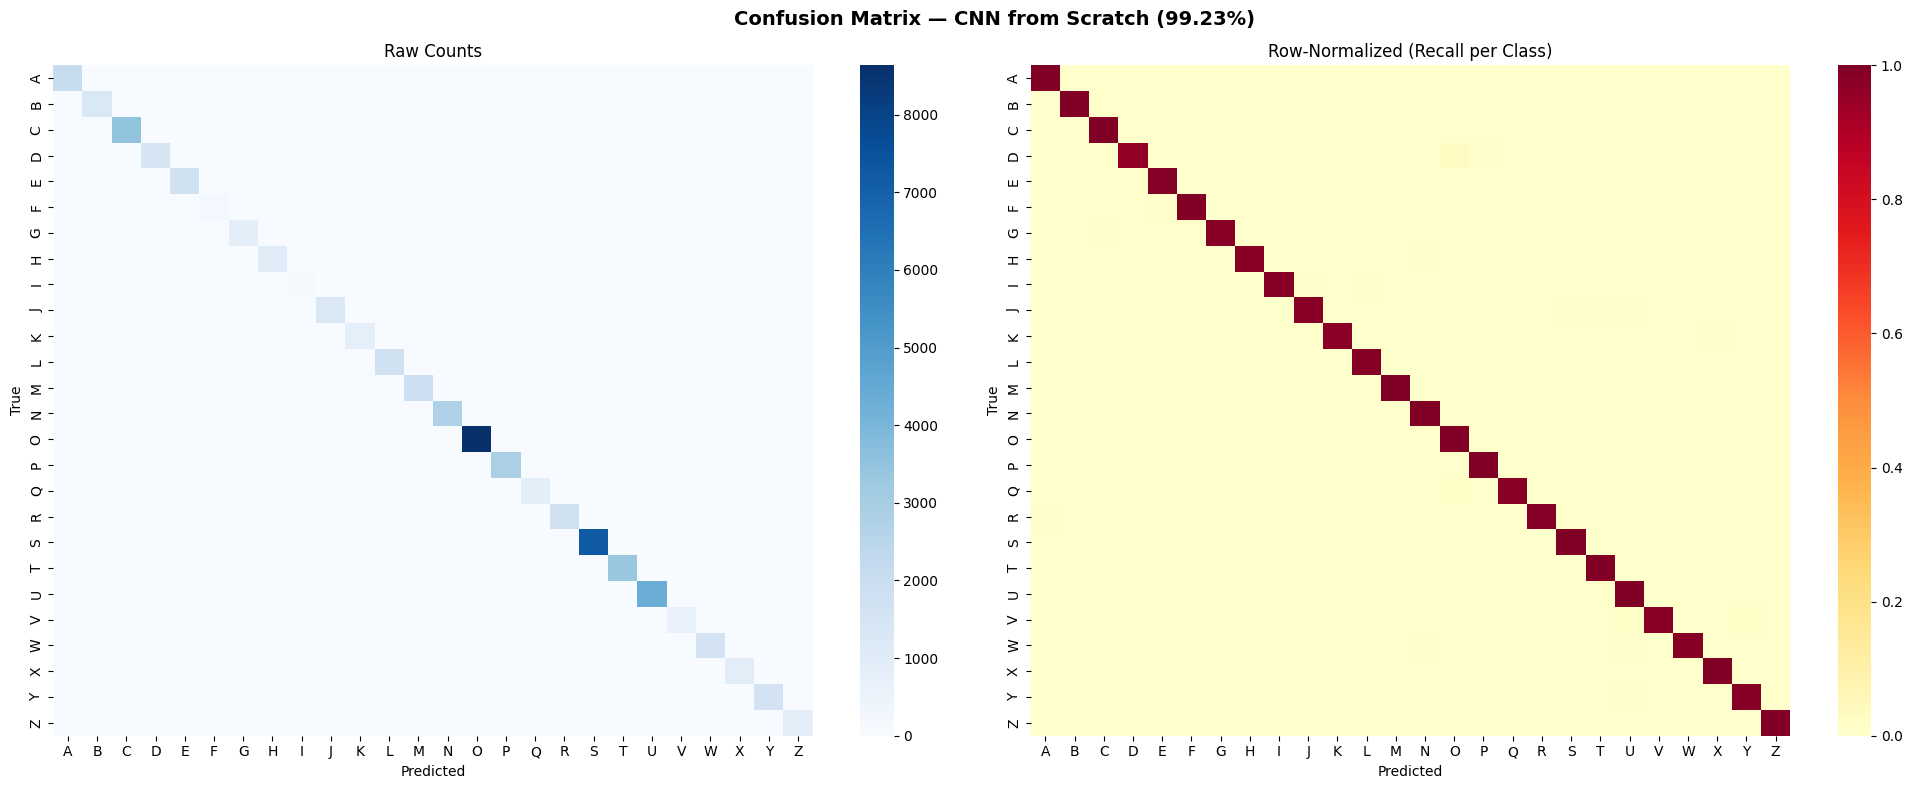


Top 5 confused pairs (true → predicted, count):
  D → O: 48 errors
  O → D: 22 errors
  C → L: 12 errors
  Y → U: 10 errors
  Q → O: 9 errors


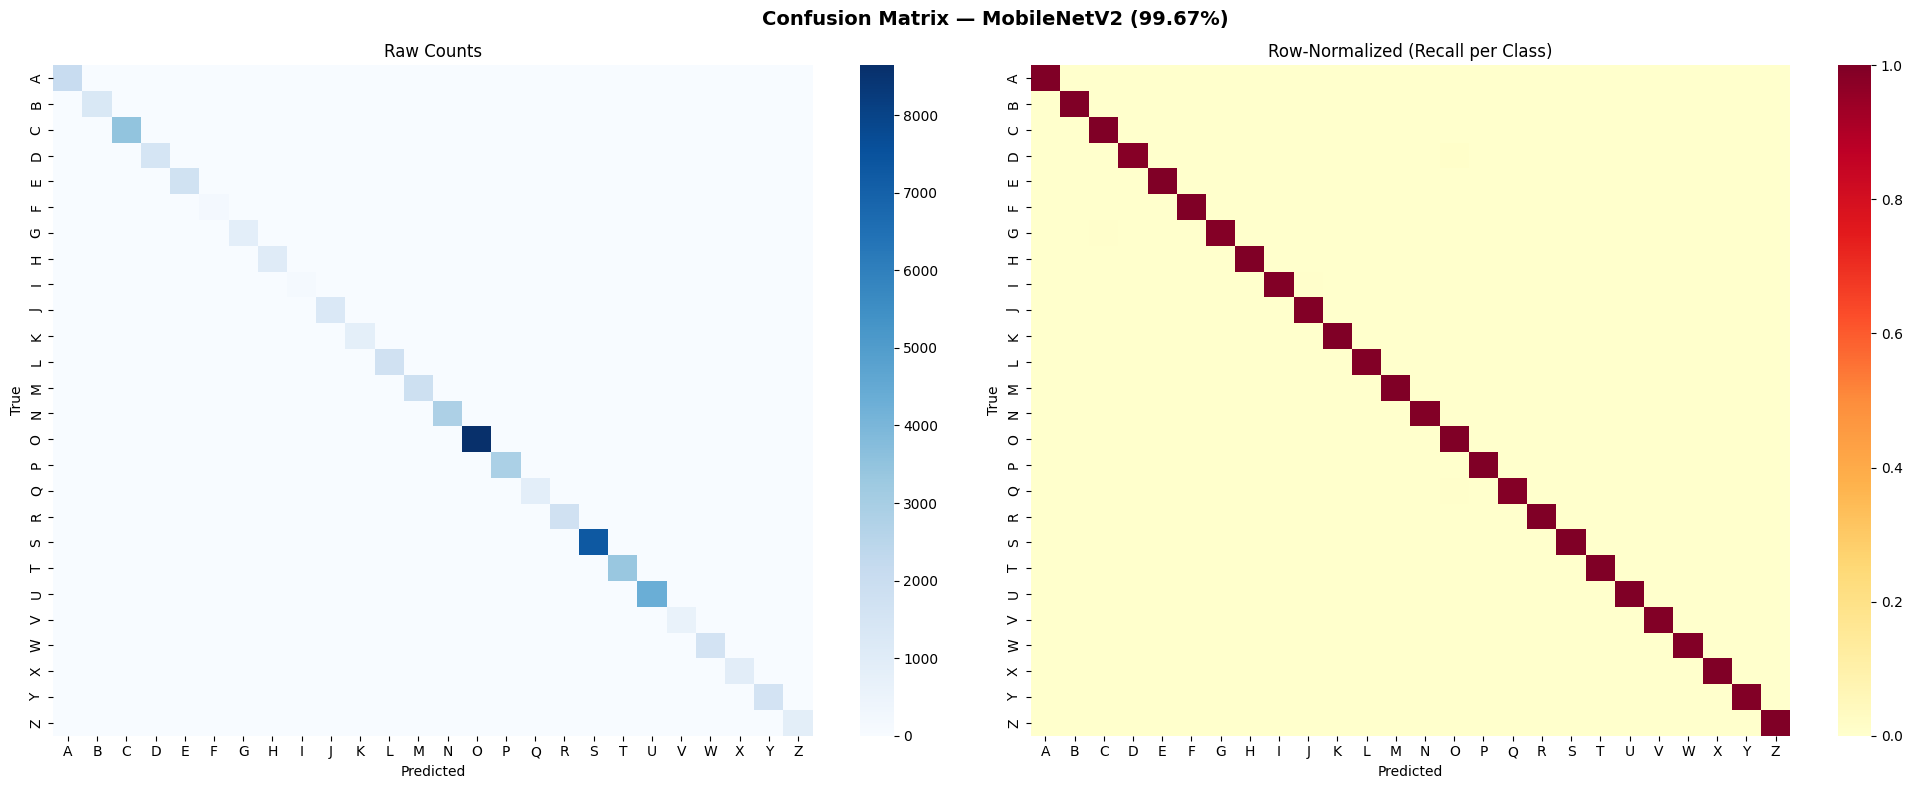


Top 5 confused pairs (true → predicted, count):
  O → D: 20 errors
  D → O: 13 errors
  P → D: 8 errors
  Q → O: 6 errors
  N → W: 5 errors


In [12]:
def plot_confusion_matrix(preds, labels, title, save_path=None):
    cm = confusion_matrix(labels, preds)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)  # row-normalized

    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    fig.suptitle(f'Confusion Matrix — {title}', fontsize=14, fontweight='bold')

    # Count matrix
    sns.heatmap(cm, ax=axes[0], annot=False, fmt='d', cmap='Blues',
                xticklabels=ALPHABET, yticklabels=ALPHABET)
    axes[0].set_title('Raw Counts')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('True')

    # Normalized matrix
    sns.heatmap(cm_norm, ax=axes[1], annot=False, fmt='.2f', cmap='YlOrRd',
                xticklabels=ALPHABET, yticklabels=ALPHABET, vmin=0, vmax=1)
    axes[1].set_title('Row-Normalized (Recall per Class)')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('True')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=120)
    plt.show()

    # Print top confusion pairs
    np.fill_diagonal(cm, 0)
    flat = cm.flatten()
    top5 = np.argsort(flat)[-5:][::-1]
    print("\nTop 5 confused pairs (true → predicted, count):")
    for idx in top5:
        true_cls = idx // NUM_CLASSES
        pred_cls = idx  % NUM_CLASSES
        print(f"  {ALPHABET[true_cls]} → {ALPHABET[pred_cls]}: {flat[idx]} errors")


plot_confusion_matrix(cnn_preds, cnn_labels, f'CNN from Scratch ({cnn_test_acc:.2f}%)', 'report_cnn_confusion.png')
plot_confusion_matrix(mob_preds, mob_labels, f'MobileNetV2 ({mob_test_acc:.2f}%)',       'report_mobilenet_confusion.png')

In [ ]:
cnn_params   = sum(p.numel() for p in OCR_CNN(NUM_CLASSES).parameters())
mob_params   = sum(p.numel() for p in models.mobilenet_v2(weights=None).parameters())

summary = {
    'Model':            ['CNN from Scratch',       'MobileNetV2 (fine-tuned)'],
    'Parameters':       [f'{cnn_params:,}',        f'{mob_params:,}'],
    'Best Val Acc':     [f"{cnn_history['best_val_acc']:.2f}%",  f"{mob_history_phase2['best_val_acc']:.2f}%"],
    'Best Epoch':       [cnn_history['best_epoch'], 5 + mob_history_phase2['best_epoch']],
    'Test Accuracy':    [f'{cnn_test_acc:.2f}%',   f'{mob_test_acc:.2f}%'],
    'Meets Target':     [cnn_test_acc >= 90,        mob_test_acc >= 90],
}

import pandas as pd
df_summary = pd.DataFrame(summary)
print("\n" + "="*60)
print("          MODEL COMPARISON SUMMARY")
print("="*60)
print(df_summary.to_string(index=False))
print("="*60)

# Determine winner
if mob_test_acc >= cnn_test_acc:
    WINNER = 'MobileNetV2'
    best_model = model_mobilenet
    best_model.load_state_dict(mob_best_state)
    best_acc = mob_test_acc
else:
    WINNER = 'CNN'
    best_model = model_cnn
    best_model.load_state_dict(cnn_best_state)
    best_acc = cnn_test_acc

print(f"\n Best model: {WINNER} ({best_acc:.2f}% test accuracy)")


          MODEL COMPARISON SUMMARY
                   Model Parameters Best Val Acc  Best Epoch Test Accuracy  Meets Target
        CNN from Scratch    179,194       99.24%          28        99.23%          True
MobileNetV2 (fine-tuned)  3,504,872       99.70%          24        99.67%          True

✅ Best model: MobileNetV2 (99.67% test accuracy)


In [14]:
# Save full checkpoint — includes architecture info for easy reload
checkpoint = {
    'model_name':     WINNER,
    'num_classes':    NUM_CLASSES,
    'class_names':    ALPHABET,
    'test_accuracy':  best_acc,
    'model_state_dict': best_model.state_dict(),
    'training_config': {
        'seed':          SEED,
        'batch_size':    BATCH_SIZE,
        'optimizer':     'AdamW',
        'loss':          'CrossEntropyLoss (label_smoothing=0.1)',
        'scheduler':     'CosineAnnealingLR',
        'augmentation':  'RandomRotation(15) + RandomAffine(translate=0.1, shear=5)',
    }
}

torch.save(checkpoint, EXPORT_PATH)
size_mb = os.path.getsize(EXPORT_PATH) / 1e6
print(f"Model exported to: {EXPORT_PATH}")
print(f"File size        : {size_mb:.1f} MB")
print(f"Test accuracy    : {best_acc:.2f}%")

Model exported to: ocr_model.pth
File size        : 11.8 MB
Test accuracy    : 99.67%


In [ ]:
import torch
import torch.nn.functional as F
from PIL import Image as PILImage

def load_ocr_model(path, device='cpu'):
    """Load the exported model for inference."""
    checkpoint = torch.load(path, map_location=device, weights_only=False)
    
    model_name = checkpoint['model_name']
    num_classes = checkpoint['num_classes']

    if model_name == 'MobileNetV2':
        model = build_mobilenetv2(num_classes, freeze_backbone=False)
    else:
        model = OCR_CNN(num_classes)

    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()
    return model, checkpoint['class_names']

@torch.no_grad()
def predict_image(model, image_path, model_name, class_names, device='cpu', top_k=3):
    """Predict the letter in a single image file."""
    if model_name == 'MobileNetV2':
        tf = mobilenet_eval_transform
    else:
        tf = cnn_eval_transform

    img = PILImage.open(image_path).convert('L')
    tensor = tf(img).unsqueeze(0).to(device)
    
    logits = model(tensor)
    probs = F.softmax(logits, dim=1).squeeze()
    
    current_top_k = min(top_k, len(probs))
    topk_probs, topk_idx = probs.topk(current_top_k)

    print(f"Prediction for: {image_path}")
    for i, (p, idx) in enumerate(zip(topk_probs, topk_idx)):
        print(f"  Top-{i+1}: {class_names[idx.item()]} ({p.item()*100:.1f}%)")
        
    return class_names[topk_idx[0].item()]

try:
    loaded_model, class_names = load_ocr_model(EXPORT_PATH, device=str(DEVICE))
    print(f"Model loaded successfully.")
    print(f"Architecture: {WINNER}, Classes: {len(class_names)}")
except Exception as e:
    print(f" Error loading model: {e}")

✅ Model loaded successfully.
Architecture: MobileNetV2, Classes: 26


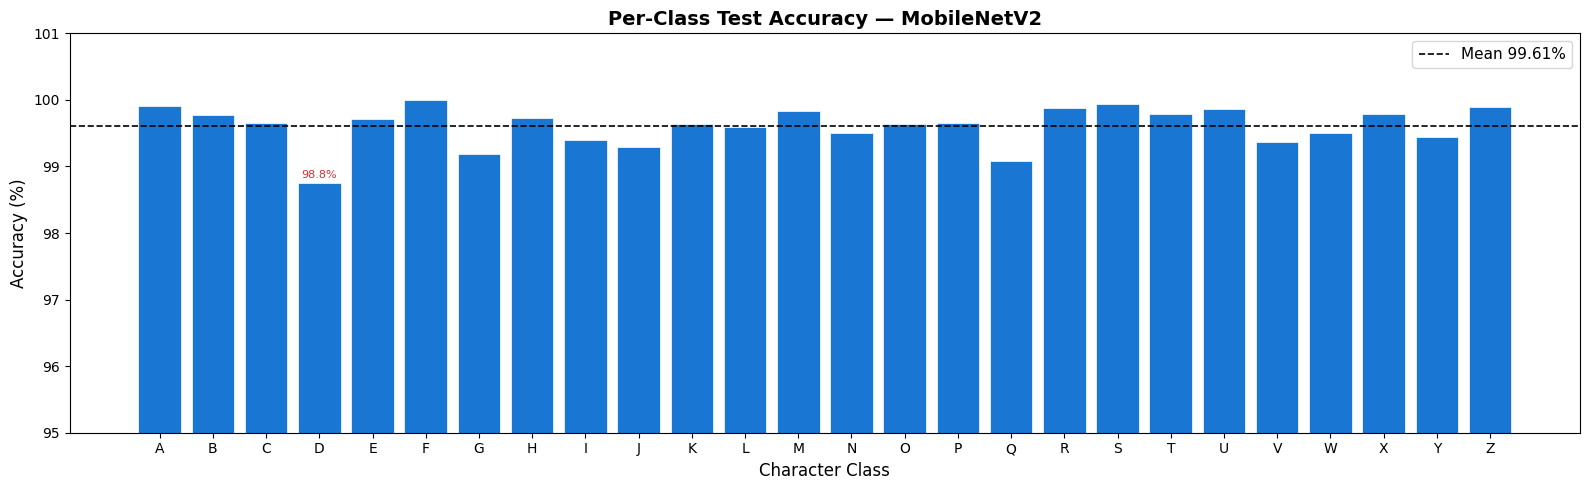


Classes below 99% accuracy:
  D: 98.75%


In [16]:
@torch.no_grad()
def per_class_accuracy(model, loader, num_classes, device):
    model.eval()
    correct = torch.zeros(num_classes)
    total   = torch.zeros(num_classes)
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        preds = model(imgs).argmax(1)
        for c in range(num_classes):
            mask = labels == c
            correct[c] += (preds[mask] == labels[mask]).sum().item()
            total[c]   += mask.sum().item()
    return (correct / total.clamp(min=1) * 100).numpy()

loader_eval = mob_test_loader if WINNER == 'MobileNetV2' else cnn_test_loader
per_class_acc = per_class_accuracy(loaded_model, loader_eval, NUM_CLASSES, DEVICE)

# Plot
fig, ax = plt.subplots(figsize=(16, 5))
colors = ['#d32f2f' if a < 98 else '#1976d2' for a in per_class_acc]
bars = ax.bar(ALPHABET, per_class_acc, color=colors, edgecolor='white', linewidth=0.5)
ax.axhline(per_class_acc.mean(), color='black', linestyle='--', linewidth=1.2,
           label=f'Mean {per_class_acc.mean():.2f}%')
ax.set_ylim(95, 101)
ax.set_xlabel('Character Class', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title(f'Per-Class Test Accuracy — {WINNER}', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)

# Annotate bars below 99%
for bar, acc, lbl in zip(bars, per_class_acc, ALPHABET):
    if acc < 99:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{acc:.1f}%', ha='center', va='bottom', fontsize=8, color='#d32f2f')

plt.tight_layout()
plt.savefig('report_per_class_accuracy.png', bbox_inches='tight', dpi=120)
plt.show()

# Print weak classes
weak = [(ALPHABET[i], per_class_acc[i]) for i in range(NUM_CLASSES) if per_class_acc[i] < 99]
print("\nClasses below 99% accuracy:")
for lbl, acc in sorted(weak, key=lambda x: x[1]):
    print(f"  {lbl}: {acc:.2f}%")

In [17]:
@torch.no_grad()
def collect_preds_labels(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs = imgs.to(device)
        preds = model(imgs).argmax(1).cpu()
        all_preds.append(preds)
        all_labels.append(labels)
    return torch.cat(all_preds).numpy(), torch.cat(all_labels).numpy()

# Reuse already-computed preds if available, else recompute
eval_preds, eval_labels = collect_preds_labels(loaded_model, loader_eval, DEVICE)

report = classification_report(eval_labels, eval_preds,
                                target_names=ALPHABET, digits=4)
print("Classification Report:")
print(report)

# Save report to text file
with open('report_classification.txt', 'w') as f:
    f.write(f"Model: {WINNER}\n")
    f.write(f"Test Accuracy: {best_acc:.2f}%\n\n")
    f.write(report)
print("Saved: report_classification.txt")

Classification Report:
              precision    recall  f1-score   support

           A     0.9981    0.9990    0.9986      2080
           B     1.0000    0.9977    0.9988      1300
           C     0.9954    0.9966    0.9960      3511
           D     0.9804    0.9875    0.9839      1520
           E     0.9982    0.9971    0.9977      1716
           F     0.9887    1.0000    0.9943       175
           G     0.9988    0.9919    0.9954       864
           H     0.9963    0.9972    0.9968      1083
           I     1.0000    0.9940    0.9970       168
           J     0.9914    0.9929    0.9922      1274
           K     0.9964    0.9964    0.9964       841
           L     0.9965    0.9960    0.9963      1738
           M     0.9984    0.9984    0.9984      1850
           N     0.9986    0.9951    0.9968      2852
           O     0.9972    0.9963    0.9968      8674
           P     0.9990    0.9966    0.9978      2901
           Q     0.9954    0.9908    0.9931       872
    

  True    Pred   Count   % of True
----------------------------------------
     O  →  D         20    (0.23%)
     D  →  O         13    (0.86%)
     P  →  D          8    (0.28%)
     Q  →  O          6    (0.69%)
     G  →  C          5    (0.58%)
     N  →  W          5    (0.18%)
     J  →  S          4    (0.31%)
     W  →  U          4    (0.25%)
     C  →  L          3    (0.09%)
     C  →  O          3    (0.09%)
     D  →  P          3    (0.20%)
     J  →  U          3    (0.24%)
     L  →  C          3    (0.17%)
     N  →  U          3    (0.11%)
     S  →  C          3    (0.04%)


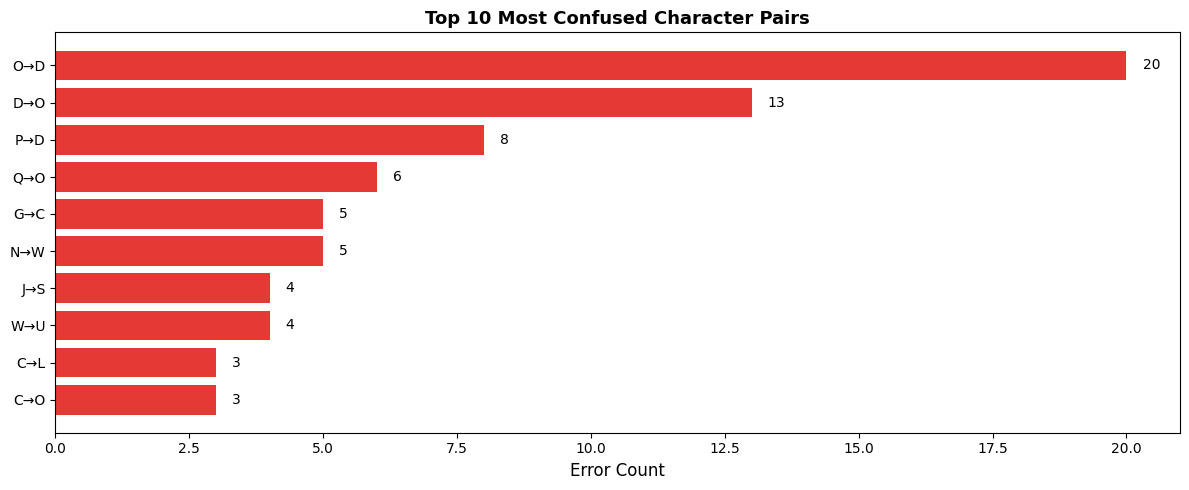

In [18]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(eval_labels, eval_preds)

# Extract all off-diagonal errors
errors = []
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if i != j and cm[i, j] > 0:
            errors.append((ALPHABET[i], ALPHABET[j], cm[i, j]))

errors.sort(key=lambda x: -x[2])

print(f"{'True':>6}  {'Pred':>6}  {'Count':>6}  {'% of True':>10}")
print("-" * 40)
for true, pred, count in errors[:15]:
    true_total = cm[ALPHABET.index(true)].sum()
    pct = count / true_total * 100
    print(f"  {true:>4}  →  {pred:<4}  {count:>6}    ({pct:.2f}%)")

# Bar chart of top-10 confused pairs
top10 = errors[:10]
labels_pairs = [f"{t}→{p}" for t, p, _ in top10]
counts = [c for _, _, c in top10]

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(labels_pairs[::-1], counts[::-1], color='#e53935')
ax.set_xlabel('Error Count', fontsize=12)
ax.set_title('Top 10 Most Confused Character Pairs', fontsize=13, fontweight='bold')
for i, (v, lbl) in enumerate(zip(counts[::-1], labels_pairs[::-1])):
    ax.text(v + 0.3, i, str(v), va='center', fontsize=10)
plt.tight_layout()
plt.savefig('report_confused_pairs.png', bbox_inches='tight', dpi=120)
plt.show()

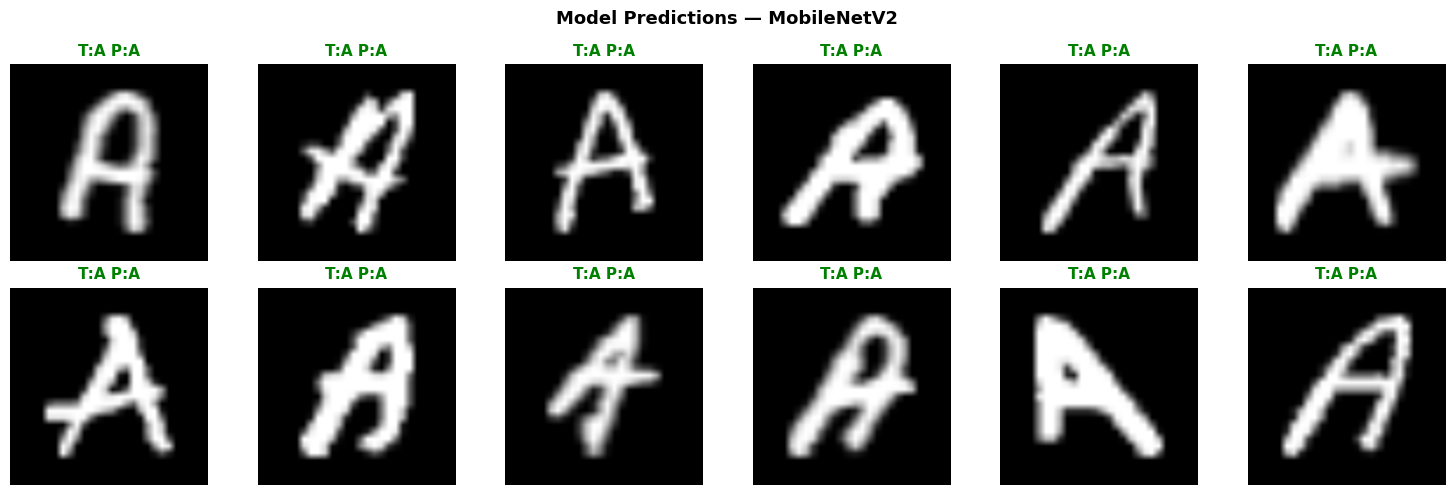

In [19]:
@torch.no_grad()
def visualize_predictions(model, loader, class_names, n=12, model_name='CNN'):
    model.eval()
    images_batch, labels_batch = next(iter(loader))
    images_batch = images_batch[:n]
    labels_batch = labels_batch[:n]

    outputs = model(images_batch.to(DEVICE))
    _, preds = outputs.max(1)

    fig, axes = plt.subplots(2, 6, figsize=(15, 5))
    fig.suptitle(f'Model Predictions — {model_name}', fontsize=13, fontweight='bold')

    for i, ax in enumerate(axes.flat):
        if i >= n:
            ax.axis('off')
            continue
        img = images_batch[i]
        if img.shape[0] == 1:
            ax.imshow(img.squeeze(), cmap='gray')
        else:
            display = img[0] * 0.229 + 0.485
            ax.imshow(display.clamp(0, 1), cmap='gray')

        true_lbl = class_names[labels_batch[i].item()]
        pred_lbl = class_names[preds[i].item()]
        color = 'green' if true_lbl == pred_lbl else 'red'
        ax.set_title(f'T:{true_lbl} P:{pred_lbl}', fontsize=11,
                     color=color, fontweight='bold')
        ax.axis('off')

    plt.tight_layout()
    plt.savefig('report_predictions.png', bbox_inches='tight', dpi=120)
    plt.show()


visualize_predictions(loaded_model, loader_eval, class_names, model_name=WINNER)

In [20]:
print("=" * 60)
print("          PROJECT DELIVERABLES COMPLETE")
print("=" * 60)
print(f" Trained Model       : {EXPORT_PATH}  ({os.path.getsize(EXPORT_PATH)/1e6:.1f} MB)")
print(f" Test Accuracy        : {best_acc:.2f}%  (Target: >90%  ✓)")
print(f" Winner               : {WINNER}")
print()
print("── Training Plots ──────────────────────────────────────")
print(f"CNN curves           : report_cnn_curves.png")
print(f" MobileNetV2 curves   : report_mobilenet_curves.png")
print()
print("── Evaluation Plots ────────────────────────────────────")
print(f" Confusion matrix CNN : report_cnn_confusion.png")
print(f" Confusion matrix MNet: report_mobilenet_confusion.png")
print(f" Per-class accuracy   : report_per_class_accuracy.png")
print(f" Confused pairs chart : report_confused_pairs.png")
print(f" Predictions grid     : report_predictions.png")
print()
print("── Reports ─────────────────────────────────────────────")
print(f" Classification report: report_classification.txt")
print("=" * 60)
print()
print("── Top Confusion Pairs (from evaluation) ───────────────")
for true, pred, count in errors[:5]:
    print(f"   {true} → {pred}: {count} errors")
print("=" * 60)

          PROJECT DELIVERABLES COMPLETE
 Trained Model       : ocr_model.pth  (11.8 MB)
 Test Accuracy        : 99.67%  (Target: >90%  ✓)
 Winner               : MobileNetV2

── Training Plots ──────────────────────────────────────
CNN curves           : report_cnn_curves.png
 MobileNetV2 curves   : report_mobilenet_curves.png

── Evaluation Plots ────────────────────────────────────
 Confusion matrix CNN : report_cnn_confusion.png
 Confusion matrix MNet: report_mobilenet_confusion.png
 Per-class accuracy   : report_per_class_accuracy.png
 Confused pairs chart : report_confused_pairs.png
 Predictions grid     : report_predictions.png

── Reports ─────────────────────────────────────────────
 Classification report: report_classification.txt

── Top Confusion Pairs (from evaluation) ───────────────
   O → D: 20 errors
   D → O: 13 errors
   P → D: 8 errors
   Q → O: 6 errors
   G → C: 5 errors
